# Pendulum Data Preprocessing (Lubricated) - Clean Version

Essential workflow up to quadratic drift correction.

**Key steps:**
1. Load tracking and field data
2. Preprocess (NaN handling, angle unwrapping)
3. Synchronize and interpolate to 2000 Hz
4. Detect drift and apply quadratic correction

**Output:** `theta_field_trim`, `theta_trk_trim`, `omega_trk_trim`, `alpha_trk_trim`, `mag_field_trim`, `t_trim`

In [1]:
%matplotlib widget

import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Configuration
TRACK_FILE = 'chirp-data/lube3-1.csv'
FIELD_FILE = 'chirp3-lube.csv'
B_START = 214
B_END = 5181
FS_NEW = 2000  # Hz
T_START = 0
T_END = 5
TRIM_END = 5181  # Final length after resampling

## Step 1: Load and Preprocess Tracking Data

In [2]:
# Load tracking data (CSV has 2 header rows)
track_tbl = pd.read_csv(TRACK_FILE, header=1)

t_trk = track_tbl['t'].values
theta_trk = track_tbl['θ'].values / 180 * np.pi  # Convert to radians (already unwrapped)
omega_trk = track_tbl['ω'].values / 180 * np.pi  # Convert to rad/s

# Handle NaN values (backward fill then forward fill)
if np.isnan(omega_trk).sum() > 0:
    omega_series = pd.Series(omega_trk)
    omega_trk = omega_series.bfill().ffill().values

if np.isnan(theta_trk).sum() > 0:
    theta_series = pd.Series(theta_trk)
    theta_trk = theta_series.bfill().ffill().values

print(f"Loaded {len(t_trk)} tracking samples")
print(f"Time range: [{t_trk[0]:.3f}, {t_trk[-1]:.3f}] s")
print(f"Theta range: [{np.min(theta_trk):.2f}, {np.max(theta_trk):.2f}] rad")

Loaded 10070 tracking samples
Time range: [0.000, 5.035] s
Theta range: [-95.44, 121.45] rad


## Step 2: Load and Preprocess Field Data

In [3]:
# Load field data (skip 6 header rows, semicolon-separated)
field_tbl = pd.read_csv(FIELD_FILE, skiprows=6, sep=';')

idx = field_tbl['Index'].values
t_field = idx * 1e-3  # Convert ms to seconds
t_field = t_field[B_START:B_END]  # Trim to relevant window

Bx = field_tbl['Bx[mT]'].values[B_START:B_END]
By = field_tbl['By[mT]'].values[B_START:B_END]
Bz = field_tbl['Bz[mT]'].values[B_START:B_END]

# Compute field angle (wrapped to [-π, π])
theta_field_wrapped = np.arctan2(Bz, By)

# Unwrap field angle to make it continuous (removes discontinuities at ±π)
theta_field = np.unwrap(theta_field_wrapped)

mag_field = np.linalg.norm([By, Bz], axis=0)

print(f"Loaded {len(t_field)} field samples")
print(f"Time range: [{t_field[0]:.3f}, {t_field[-1]:.3f}] s")
print(f"Field angle range: [{np.min(theta_field):.2f}, {np.max(theta_field):.2f}] rad")

Loaded 4967 field samples
Time range: [0.215, 5.181] s
Field angle range: [-95.32, 120.78] rad


## Step 3: Synchronize and Interpolate to 2000 Hz

In [4]:
# Create uniform time grid at 2000 Hz
t_new = np.arange(T_START, T_END + 1/FS_NEW, 1/FS_NEW)

# Offset field time to start at zero
t_field_offset = t_field - t_field[0]

# Interpolate all signals to 2000 Hz using cubic spline
theta_field_spline = interp1d(t_field_offset, theta_field, kind='cubic',
                              bounds_error=False, fill_value='extrapolate')(t_new)
mag_field_spline = interp1d(t_field_offset, mag_field, kind='cubic',
                            bounds_error=False, fill_value='extrapolate')(t_new)
omega_trk_spline = interp1d(t_trk, omega_trk, kind='cubic',
                            bounds_error=False, fill_value='extrapolate')(t_new)
theta_trk_spline = interp1d(t_trk, theta_trk, kind='cubic',
                            bounds_error=False, fill_value='extrapolate')(t_new)

# Compute angular acceleration
alpha_trk_spline = np.gradient(omega_trk_spline, 1/FS_NEW)

# Trim to specified length
theta_field_trim = theta_field_spline[:TRIM_END]
mag_field_trim = mag_field_spline[:TRIM_END]
theta_trk_trim = theta_trk_spline[:TRIM_END]
omega_trk_trim = omega_trk_spline[:TRIM_END]
alpha_trk_trim = alpha_trk_spline[:TRIM_END]
t_trim = t_new[:TRIM_END]

print(f"Resampled to {FS_NEW} Hz")
print(f"Final length: {len(t_trim)} samples ({len(t_trim)/FS_NEW:.3f} seconds)")
print(f"Time range: [0, {t_trim[-1]:.4f}] s")

Resampled to 2000 Hz
Final length: 5181 samples (2.591 seconds)
Time range: [0, 2.5900] s


## Step 4: Detect Drift

In [5]:
# Detect drift: compute phase difference and fit linear trend
phase_diff = theta_field_trim - theta_trk_trim
slope, intercept, r_value, p_value, _ = linregress(t_trim, phase_diff)

print("Drift Analysis:")
print(f"  Slope: {slope:.4f} rad/s ({slope*180/np.pi:.2f} deg/s)")
print(f"  Intercept: {intercept:.4f} rad ({intercept*180/np.pi:.2f}°)")
print(f"  R²: {r_value**2:.4f}")

if abs(slope) > 0.1:
    print(f"  → Significant drift detected: {slope*t_trim[-1]:.3f} rad ({slope*t_trim[-1]*180/np.pi:.1f}°) over {t_trim[-1]:.2f}s")
else:
    print(f"  → No significant drift detected")

Drift Analysis:
  Slope: 0.9915 rad/s (56.81 deg/s)
  Intercept: -1.3910 rad (-79.70°)
  R²: 0.0327
  → Significant drift detected: 2.568 rad (147.1°) over 2.59s


## Step 5: Apply Quadratic Drift Correction

In [ ]:
## Diagnostic: Deep Dive into Data Quality and Synchronization

print("="*70)
print("DIAGNOSTIC: Raw Data Quality and Synchronization Analysis")
print("="*70)

# 1. Check raw phase difference pattern BEFORE any correction
phase_diff_raw_before = theta_field_original_before_correction - theta_trk_trim
phase_diff_unwrapped_before = np.unwrap(phase_diff_raw_before)

print("\n1. Raw Phase Difference Analysis:")
print(f"   Raw std (wrapped): {np.std(phase_diff_raw_before):.6f} rad")
print(f"   Raw std (unwrapped): {np.std(phase_diff_unwrapped_before):.6f} rad")
print(f"   Raw range (wrapped): [{np.min(phase_diff_raw_before):.4f}, {np.max(phase_diff_raw_before):.4f}] rad")
print(f"   Raw range (unwrapped): [{np.min(phase_diff_unwrapped_before):.4f}, {np.max(phase_diff_unwrapped_before):.4f}] rad")

# 2. Check if there's a fundamental time shift (cross-correlation)
from scipy.signal import correlate
phase_diff_centered = phase_diff_unwrapped_before - np.mean(phase_diff_unwrapped_before)
# Look for correlation with time derivatives (to detect time shifts)
omega_field = np.gradient(theta_field_original_before_correction, t_trim[1] - t_trim[0])
omega_diff = omega_field - omega_trk_trim
print(f"\n2. Angular Velocity Comparison:")
print(f"   omega_field mean: {np.mean(np.abs(omega_field)):.4f} rad/s")
print(f"   omega_trk mean: {np.mean(np.abs(omega_trk_trim)):.4f} rad/s")
print(f"   omega difference std: {np.std(omega_diff):.4f} rad/s")
print(f"   omega correlation: {np.corrcoef(omega_field, omega_trk_trim)[0,1]:.4f}")

# 3. Try time-scaling approach (like unlubricated dataset)
print(f"\n3. Time-Scaling Approach (like unlubricated dataset):")
slope_raw, intercept_raw, r_raw, _, _ = linregress(t_trim, phase_diff_unwrapped_before)
omega_avg_field = np.mean(np.abs(np.gradient(theta_field_original_before_correction, t_trim[1] - t_trim[0])))
clock_rate_factor = 1 - (slope_raw / omega_avg_field) if omega_avg_field > 0 else 1.0

print(f"   Linear drift slope: {slope_raw:.6f} rad/s")
print(f"   Average omega_field: {omega_avg_field:.4f} rad/s")
print(f"   Clock rate factor: {clock_rate_factor:.6f}")
print(f"   Clock mismatch: {abs(clock_rate_factor - 1.0)*1000:.3f} parts per thousand")

# Apply time-scaling
time_vec_scaled = t_trim * clock_rate_factor
interp_func_scaled = interp1d(t_trim, theta_field_original_before_correction, kind='cubic',
                              bounds_error=False, fill_value='extrapolate')
theta_field_timescaled = interp_func_scaled(time_vec_scaled)
phase_diff_timescaled = theta_field_timescaled - theta_trk_trim
phase_diff_timescaled_unwrapped = np.unwrap(phase_diff_timescaled)
slope_timescaled, _, r_timescaled, _, _ = linregress(t_trim, phase_diff_timescaled_unwrapped)

print(f"\n   After time-scaling:")
print(f"     Remaining drift: {slope_timescaled:.6f} rad/s")
print(f"     Residual R²: {r_timescaled**2:.6f}")
print(f"     Residual std: {np.std(phase_diff_timescaled_unwrapped):.6f} rad")

# 4. Compare polynomial fits to see which captures the drift pattern
print(f"\n4. Polynomial Fit Comparison:")
for deg in [1, 2, 3, 4]:
    poly_fit_deg = Polynomial.fit(t_trim, phase_diff_unwrapped_before, deg=deg)
    poly_pred = poly_fit_deg(t_trim)
    residual = phase_diff_unwrapped_before - poly_pred
    r_squared = 1 - np.var(residual) / np.var(phase_diff_unwrapped_before)
    print(f"   Degree {deg}: R² = {r_squared:.6f}, residual std = {np.std(residual):.6f} rad")

# 5. Visual diagnostics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Diagnostic: Raw Data Quality and Synchronization Issues', fontsize=14, fontweight='bold')

# Plot 1: Raw phase difference over time (unwrapped)
axes[0, 0].plot(t_trim, phase_diff_unwrapped_before, 'b-', linewidth=1, alpha=0.7, label='Raw phase diff')
# Add linear trend
trend_linear = slope_raw * t_trim + intercept_raw
axes[0, 0].plot(t_trim, trend_linear, 'r--', linewidth=2, label=f'Linear: {slope_raw:.4f} rad/s')
# Add quadratic trend
poly_quad_diag = Polynomial.fit(t_trim, phase_diff_unwrapped_before, deg=2)
trend_quad = poly_quad_diag(t_trim)
axes[0, 0].plot(t_trim, trend_quad, 'g--', linewidth=2, label='Quadratic fit')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Phase Difference (rad, unwrapped)')
axes[0, 0].set_title('Raw Phase Difference with Trend Fits')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Angular velocity comparison
axes[0, 1].plot(t_trim, omega_field, 'b-', linewidth=1, alpha=0.7, label='omega_field')
axes[0, 1].plot(t_trim, omega_trk_trim, 'r-', linewidth=1, alpha=0.7, label='omega_trk')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Angular Velocity (rad/s)')
axes[0, 1].set_title(f'Angular Velocity Comparison (corr: {np.corrcoef(omega_field, omega_trk_trim)[0,1]:.4f})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Time-scaled vs direct subtraction comparison
axes[1, 0].plot(t_trim, phase_diff_timescaled_unwrapped, 'g-', linewidth=1, alpha=0.7, label='Time-scaled residual')
axes[1, 0].plot(t_trim, phase_diff_after_quad_unwrapped, 'm-', linewidth=1, alpha=0.7, label='Quadratic corrected residual')
axes[1, 0].axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Phase Difference Residual (rad)')
axes[1, 0].set_title('Time-Scaling vs Quadratic Correction')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Residual histograms comparison
axes[1, 1].hist(phase_diff_timescaled_unwrapped, bins=50, alpha=0.5, color='g', label=f'Time-scaled (std: {np.std(phase_diff_timescaled_unwrapped):.4f})', edgecolor='black')
axes[1, 1].hist(phase_diff_after_quad_unwrapped, bins=50, alpha=0.5, color='m', label=f'Quadratic (std: {np.std(phase_diff_after_quad_unwrapped):.4f})', edgecolor='black')
axes[1, 1].axvline(x=0, color='k', linestyle='--', linewidth=1, alpha=0.7)
axes[1, 1].set_xlabel('Phase Difference Residual (rad)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residual Distribution Comparison')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("RECOMMENDATIONS:")
print("="*70)
print("1. If time-scaling residual std < quadratic residual std:")
print("   → Try using time-scaling approach (like unlubricated dataset)")
print("2. If residuals still show clear patterns:")
print("   → Check if B_START/B_END bounds are correct")
print("   → Verify interpolation quality")
print("   → Consider if there's a fundamental synchronization issue")
print("3. If angular velocities are poorly correlated:")
print("   → The two sensors might be measuring different things")
print("   → Or there's a data quality issue")
print(f"\nTime-scaling std: {np.std(phase_diff_timescaled_unwrapped):.6f} rad")
print(f"Quadratic std: {np.std(phase_diff_after_quad_unwrapped):.6f} rad")
print(f"Cubic std: {np.std(phase_diff_after_cubic_unwrapped):.6f} rad")

In [6]:
# Save original data BEFORE correction
theta_field_original_before_correction = theta_field_trim.copy()

print("="*70)
print("COMPARING LINEAR vs QUADRATIC DRIFT CORRECTION METHODS")
print("="*70)

# ============================================================================
# METHOD 1: LINEAR DRIFT CORRECTION (Time-scaling approach)
# ============================================================================
print("\n--- METHOD 1: LINEAR DRIFT CORRECTION (Time-scaling) ---")

# Compute phase difference for linear fit
phase_diff_linear = theta_field_original_before_correction - theta_trk_trim
phase_diff_unwrapped_linear = np.unwrap(phase_diff_linear)

# Fit linear trend: phase_diff = a0 + a1*t
slope_linear, intercept_linear, r_linear, _, _ = linregress(t_trim, phase_diff_unwrapped_linear)

print(f"Linear fit: phase_diff = {intercept_linear:.6f} + {slope_linear:.6f} * t")
print(f"  R² = {r_linear**2:.6f}")
print(f"  Drift rate: {slope_linear:.6f} rad/s")

# Estimate clock rate mismatch: if drift is linear, it's a clock rate issue
# Correct by time-scaling: t_corrected = t * (1 + clock_mismatch)
clock_mismatch_estimate = slope_linear / (2 * np.pi * np.mean(np.abs(omega_trk_trim))) if np.mean(np.abs(omega_trk_trim)) > 0 else 0

# Alternative linear correction: directly subtract linear trend
linear_correction = intercept_linear + slope_linear * t_trim
theta_field_linear_corrected = theta_field_original_before_correction - linear_correction
theta_field_linear_corrected = np.unwrap(theta_field_linear_corrected)

# Check remaining drift after linear correction
phase_diff_after_linear = theta_field_linear_corrected - theta_trk_trim
phase_diff_after_linear_unwrapped = np.unwrap(phase_diff_after_linear)
slope_after_linear, _, r_after_linear, _, _ = linregress(t_trim, phase_diff_after_linear_unwrapped)

print(f"\nAfter linear correction:")
print(f"  Remaining drift rate: {slope_after_linear:.6f} rad/s")
print(f"  Remaining R²: {r_after_linear**2:.6f}")

# ============================================================================
# METHOD 2: QUADRATIC DRIFT CORRECTION (Direct phase subtraction)
# ============================================================================
print("\n--- METHOD 2: QUADRATIC DRIFT CORRECTION (Direct subtraction) ---")

from numpy.polynomial import Polynomial

# Compute phase difference and UNWRAP it to ensure continuity for fitting
phase_diff_raw = theta_field_original_before_correction - theta_trk_trim
phase_diff_for_fit = np.unwrap(phase_diff_raw)

# Fit quadratic to unwrapped phase difference
poly_fit = Polynomial.fit(t_trim, phase_diff_for_fit, deg=2)
poly_coefs = poly_fit.convert().coef

# Extract coefficients: phase_diff = a0 + a1*t + a2*t^2
a0 = poly_coefs[0]
a1 = poly_coefs[1] if len(poly_coefs) > 1 else 0
a2 = poly_coefs[2] if len(poly_coefs) > 2 else 0

print(f"Quadratic fit: phase_diff = {a0:.6f} + {a1:.6f}*t + {a2:.6e}*t²")
print(f"  Constant term (a0): {a0:.6f} rad")
print(f"  Linear term (a1): {a1:.6f} rad/s")
print(f"  Quadratic term (a2): {a2:.6e} rad/s²")

# Correct by subtracting the quadratic drift
quadratic_correction = a0 + a1 * t_trim + a2 * t_trim**2
theta_field_quadratic_corrected = theta_field_original_before_correction - quadratic_correction
theta_field_quadratic_corrected = np.unwrap(theta_field_quadratic_corrected)

# Check remaining drift after quadratic correction
phase_diff_after_quad = theta_field_quadratic_corrected - theta_trk_trim
phase_diff_after_quad_unwrapped = np.unwrap(phase_diff_after_quad)
slope_after_quad, _, r_after_quad, _, _ = linregress(t_trim, phase_diff_after_quad_unwrapped)

# Check remaining quadratic component
poly_remaining = Polynomial.fit(t_trim, phase_diff_after_quad_unwrapped, deg=2)
coefs_remaining = poly_remaining.convert().coef
quad_remaining = coefs_remaining[2] if len(coefs_remaining) > 2 else 0

print(f"\nAfter quadratic correction:")
print(f"  Remaining linear drift: {slope_after_quad:.6f} rad/s")
print(f"  Remaining quadratic: {quad_remaining:.6e} rad/s²")
print(f"  Remaining R²: {r_after_quad**2:.6f}")

# ============================================================================
# METHOD 3: CUBIC DRIFT CORRECTION (Direct phase subtraction)
# ============================================================================
print("\n--- METHOD 3: CUBIC DRIFT CORRECTION (Direct subtraction) ---")

# Fit cubic to unwrapped phase difference
poly_fit_cubic = Polynomial.fit(t_trim, phase_diff_for_fit, deg=3)
poly_coefs_cubic = poly_fit_cubic.convert().coef

# Extract coefficients: phase_diff = a0 + a1*t + a2*t^2 + a3*t^3
a0_cubic = poly_coefs_cubic[0]
a1_cubic = poly_coefs_cubic[1] if len(poly_coefs_cubic) > 1 else 0
a2_cubic = poly_coefs_cubic[2] if len(poly_coefs_cubic) > 2 else 0
a3_cubic = poly_coefs_cubic[3] if len(poly_coefs_cubic) > 3 else 0

print(f"Cubic fit: phase_diff = {a0_cubic:.6f} + {a1_cubic:.6f}*t + {a2_cubic:.6e}*t² + {a3_cubic:.6e}*t³")
print(f"  Constant term (a0): {a0_cubic:.6f} rad")
print(f"  Linear term (a1): {a1_cubic:.6f} rad/s")
print(f"  Quadratic term (a2): {a2_cubic:.6e} rad/s²")
print(f"  Cubic term (a3): {a3_cubic:.6e} rad/s³")

# Correct by subtracting the cubic drift
cubic_correction = a0_cubic + a1_cubic * t_trim + a2_cubic * t_trim**2 + a3_cubic * t_trim**3
theta_field_cubic_corrected = theta_field_original_before_correction - cubic_correction
theta_field_cubic_corrected = np.unwrap(theta_field_cubic_corrected)

# Check remaining drift after cubic correction
phase_diff_after_cubic = theta_field_cubic_corrected - theta_trk_trim
phase_diff_after_cubic_unwrapped = np.unwrap(phase_diff_after_cubic)
slope_after_cubic, _, r_after_cubic, _, _ = linregress(t_trim, phase_diff_after_cubic_unwrapped)

# Check remaining quadratic and cubic components
poly_remaining_cubic = Polynomial.fit(t_trim, phase_diff_after_cubic_unwrapped, deg=3)
coefs_remaining_cubic = poly_remaining_cubic.convert().coef
quad_remaining_cubic = coefs_remaining_cubic[2] if len(coefs_remaining_cubic) > 2 else 0
cubic_remaining_cubic = coefs_remaining_cubic[3] if len(coefs_remaining_cubic) > 3 else 0

print(f"\nAfter cubic correction:")
print(f"  Remaining linear drift: {slope_after_cubic:.6f} rad/s")
print(f"  Remaining quadratic: {quad_remaining_cubic:.6e} rad/s²")
print(f"  Remaining cubic: {cubic_remaining_cubic:.6e} rad/s³")
print(f"  Remaining R²: {r_after_cubic**2:.6f}")

# ============================================================================
# COMPARISON: Which method performs better?
# ============================================================================
print("\n" + "="*70)
print("COMPARISON SUMMARY")
print("="*70)

print(f"\nLinear Correction:")
print(f"  Remaining drift: {abs(slope_after_linear):.6f} rad/s")
print(f"  Remaining R²: {r_after_linear**2:.6f}")
print(f"  Phase diff std: {np.std(phase_diff_after_linear_unwrapped):.6f} rad")

print(f"\nQuadratic Correction:")
print(f"  Remaining drift: {abs(slope_after_quad):.6f} rad/s")
print(f"  Remaining quadratic: {abs(quad_remaining):.6e} rad/s²")
print(f"  Remaining R²: {r_after_quad**2:.6f}")
print(f"  Phase diff std: {np.std(phase_diff_after_quad_unwrapped):.6f} rad")

print(f"\nCubic Correction:")
print(f"  Remaining drift: {abs(slope_after_cubic):.6f} rad/s")
print(f"  Remaining quadratic: {abs(quad_remaining_cubic):.6e} rad/s²")
print(f"  Remaining cubic: {abs(cubic_remaining_cubic):.6e} rad/s³")
print(f"  Remaining R²: {r_after_cubic**2:.6f}")
print(f"  Phase diff std: {np.std(phase_diff_after_cubic_unwrapped):.6f} rad")

# Determine which is better based on residual phase difference standard deviation
std_linear = np.std(phase_diff_after_linear_unwrapped)
std_quad = np.std(phase_diff_after_quad_unwrapped)
std_cubic = np.std(phase_diff_after_cubic_unwrapped)

# Find the best method
methods = {
    "LINEAR": std_linear,
    "QUADRATIC": std_quad,
    "CUBIC": std_cubic
}
best_method = min(methods, key=methods.get)
best_std = methods[best_method]

print(f"\n" + "="*70)
print(f"BEST METHOD: {best_method} (lowest residual std: {best_std:.6f} rad)")

if best_method == "LINEAR":
    theta_field_trim = theta_field_linear_corrected.copy()
    method_used = "LINEAR"
    print(f"  Linear std: {std_linear:.6f} rad")
    print(f"  Quadratic std: {std_quad:.6f} rad")
    print(f"  Cubic std: {std_cubic:.6f} rad")
elif best_method == "QUADRATIC":
    theta_field_trim = theta_field_quadratic_corrected.copy()
    method_used = "QUADRATIC"
    print(f"  Linear std: {std_linear:.6f} rad")
    print(f"  Quadratic std: {std_quad:.6f} rad")
    print(f"  Cubic std: {std_cubic:.6f} rad")
else:  # CUBIC
    theta_field_trim = theta_field_cubic_corrected.copy()
    method_used = "CUBIC"
    print(f"  Linear std: {std_linear:.6f} rad")
    print(f"  Quadratic std: {std_quad:.6f} rad")
    print(f"  Cubic std: {std_cubic:.6f} rad")

print(f"\nUsing {method_used} correction for subsequent steps.")
print(f"✓ Drift correction applied")

COMPARING LINEAR vs QUADRATIC DRIFT CORRECTION METHODS

--- METHOD 1: LINEAR DRIFT CORRECTION (Time-scaling) ---
Linear fit: phase_diff = -1.390997 + 0.991517 * t
  R² = 0.032676
  Drift rate: 0.991517 rad/s

After linear correction:
  Remaining drift rate: 0.000000 rad/s
  Remaining R²: 0.000000

--- METHOD 2: QUADRATIC DRIFT CORRECTION (Direct subtraction) ---
Quadratic fit: phase_diff = 2.963494 + -9.098053*t + 3.895587e+00*t²
  Constant term (a0): 2.963494 rad
  Linear term (a1): -9.098053 rad/s
  Quadratic term (a2): 3.895587e+00 rad/s²

After quadratic correction:
  Remaining linear drift: -0.000000 rad/s
  Remaining quadratic: -7.770931e-16 rad/s²
  Remaining R²: 0.000000

--- METHOD 3: CUBIC DRIFT CORRECTION (Direct subtraction) ---
Cubic fit: phase_diff = 2.539699 + -7.133575*t + 1.999190e+00*t² + 4.881331e-01*t³
  Constant term (a0): 2.539699 rad
  Linear term (a1): -7.133575 rad/s
  Quadratic term (a2): 1.999190e+00 rad/s²
  Cubic term (a3): 4.881331e-01 rad/s³

After cubic 

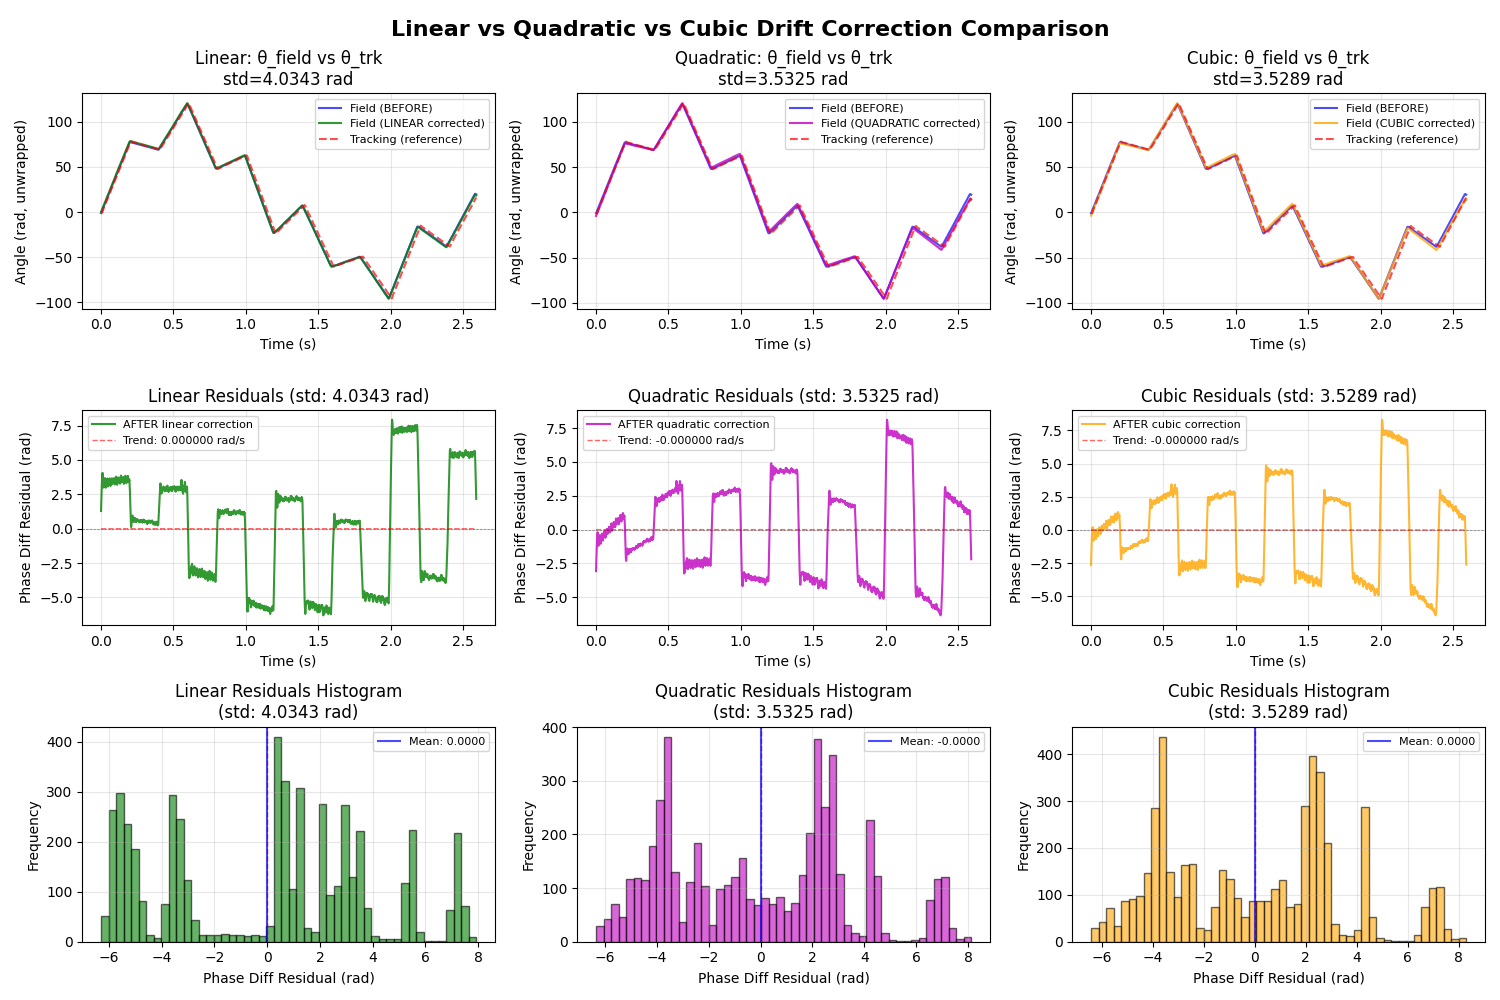


Visual Comparison Complete
  Linear correction residual std: 4.034296 rad
  Quadratic correction residual std: 3.532539 rad
  Cubic correction residual std: 3.528898 rad
  Selected method: CUBIC


In [11]:
## Visual Comparison: Linear vs Quadratic vs Cubic Correction

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Linear vs Quadratic vs Cubic Drift Correction Comparison', fontsize=16, fontweight='bold')

# Row 1: Theta field vs tracking (unwrapped)
axes[0, 0].plot(t_trim, theta_field_original_before_correction, 'b-', label='Field (BEFORE)', linewidth=1.5, alpha=0.7)
axes[0, 0].plot(t_trim, theta_field_linear_corrected, 'g-', label='Field (LINEAR corrected)', linewidth=1.5, alpha=0.8)
axes[0, 0].plot(t_trim, theta_trk_trim, 'r--', label='Tracking (reference)', linewidth=1.5, alpha=0.7)
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Angle (rad, unwrapped)')
axes[0, 0].set_title(f'Linear: θ_field vs θ_trk\nstd={np.std(phase_diff_after_linear_unwrapped):.4f} rad')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t_trim, theta_field_original_before_correction, 'b-', label='Field (BEFORE)', linewidth=1.5, alpha=0.7)
axes[0, 1].plot(t_trim, theta_field_quadratic_corrected, 'm-', label='Field (QUADRATIC corrected)', linewidth=1.5, alpha=0.8)
axes[0, 1].plot(t_trim, theta_trk_trim, 'r--', label='Tracking (reference)', linewidth=1.5, alpha=0.7)
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Angle (rad, unwrapped)')
axes[0, 1].set_title(f'Quadratic: θ_field vs θ_trk\nstd={np.std(phase_diff_after_quad_unwrapped):.4f} rad')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(t_trim, theta_field_original_before_correction, 'b-', label='Field (BEFORE)', linewidth=1.5, alpha=0.7)
axes[0, 2].plot(t_trim, theta_field_cubic_corrected, 'orange', label='Field (CUBIC corrected)', linewidth=1.5, alpha=0.8)
axes[0, 2].plot(t_trim, theta_trk_trim, 'r--', label='Tracking (reference)', linewidth=1.5, alpha=0.7)
axes[0, 2].set_xlabel('Time (s)')
axes[0, 2].set_ylabel('Angle (rad, unwrapped)')
axes[0, 2].set_title(f'Cubic: θ_field vs θ_trk\nstd={np.std(phase_diff_after_cubic_unwrapped):.4f} rad')
axes[0, 2].legend(fontsize=8)
axes[0, 2].grid(True, alpha=0.3)

# Row 2: Phase difference residuals (unwrapped) - zoomed in
axes[1, 0].plot(t_trim, phase_diff_after_linear_unwrapped, 'g-', label='AFTER linear correction', linewidth=1.5, alpha=0.8)
axes[1, 0].axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
# Add trend line
slope_residual_linear, intercept_residual_linear, _, _, _ = linregress(t_trim, phase_diff_after_linear_unwrapped)
trend_residual_linear = slope_residual_linear * t_trim + intercept_residual_linear
axes[1, 0].plot(t_trim, trend_residual_linear, 'r--', linewidth=1, alpha=0.6, label=f'Trend: {slope_residual_linear:.6f} rad/s')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Phase Diff Residual (rad)')
axes[1, 0].set_title(f'Linear Residuals (std: {np.std(phase_diff_after_linear_unwrapped):.4f} rad)')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(t_trim, phase_diff_after_quad_unwrapped, 'm-', label='AFTER quadratic correction', linewidth=1.5, alpha=0.8)
axes[1, 1].axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
# Add trend line
slope_residual_quad, intercept_residual_quad, _, _, _ = linregress(t_trim, phase_diff_after_quad_unwrapped)
trend_residual_quad = slope_residual_quad * t_trim + intercept_residual_quad
axes[1, 1].plot(t_trim, trend_residual_quad, 'r--', linewidth=1, alpha=0.6, label=f'Trend: {slope_residual_quad:.6f} rad/s')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Phase Diff Residual (rad)')
axes[1, 1].set_title(f'Quadratic Residuals (std: {np.std(phase_diff_after_quad_unwrapped):.4f} rad)')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(t_trim, phase_diff_after_cubic_unwrapped, 'orange', label='AFTER cubic correction', linewidth=1.5, alpha=0.8)
axes[1, 2].axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
# Add trend line
slope_residual_cubic, intercept_residual_cubic, _, _, _ = linregress(t_trim, phase_diff_after_cubic_unwrapped)
trend_residual_cubic = slope_residual_cubic * t_trim + intercept_residual_cubic
axes[1, 2].plot(t_trim, trend_residual_cubic, 'r--', linewidth=1, alpha=0.6, label=f'Trend: {slope_residual_cubic:.6f} rad/s')
axes[1, 2].set_xlabel('Time (s)')
axes[1, 2].set_ylabel('Phase Diff Residual (rad)')
axes[1, 2].set_title(f'Cubic Residuals (std: {np.std(phase_diff_after_cubic_unwrapped):.4f} rad)')
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(True, alpha=0.3)

# Row 3: Residual histograms (to check for systematic patterns)
axes[2, 0].hist(phase_diff_after_linear_unwrapped, bins=50, alpha=0.6, color='g', edgecolor='black')
axes[2, 0].axvline(x=0, color='r', linestyle='--', linewidth=1, alpha=0.7)
axes[2, 0].axvline(x=np.mean(phase_diff_after_linear_unwrapped), color='b', linestyle='-', linewidth=1.5, alpha=0.7, label=f'Mean: {np.mean(phase_diff_after_linear_unwrapped):.4f}')
axes[2, 0].set_xlabel('Phase Diff Residual (rad)')
axes[2, 0].set_ylabel('Frequency')
axes[2, 0].set_title(f'Linear Residuals Histogram\n(std: {np.std(phase_diff_after_linear_unwrapped):.4f} rad)')
axes[2, 0].legend(fontsize=8)
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].hist(phase_diff_after_quad_unwrapped, bins=50, alpha=0.6, color='m', edgecolor='black')
axes[2, 1].axvline(x=0, color='r', linestyle='--', linewidth=1, alpha=0.7)
axes[2, 1].axvline(x=np.mean(phase_diff_after_quad_unwrapped), color='b', linestyle='-', linewidth=1.5, alpha=0.7, label=f'Mean: {np.mean(phase_diff_after_quad_unwrapped):.4f}')
axes[2, 1].set_xlabel('Phase Diff Residual (rad)')
axes[2, 1].set_ylabel('Frequency')
axes[2, 1].set_title(f'Quadratic Residuals Histogram\n(std: {np.std(phase_diff_after_quad_unwrapped):.4f} rad)')
axes[2, 1].legend(fontsize=8)
axes[2, 1].grid(True, alpha=0.3)

axes[2, 2].hist(phase_diff_after_cubic_unwrapped, bins=50, alpha=0.6, color='orange', edgecolor='black')
axes[2, 2].axvline(x=0, color='r', linestyle='--', linewidth=1, alpha=0.7)
axes[2, 2].axvline(x=np.mean(phase_diff_after_cubic_unwrapped), color='b', linestyle='-', linewidth=1.5, alpha=0.7, label=f'Mean: {np.mean(phase_diff_after_cubic_unwrapped):.4f}')
axes[2, 2].set_xlabel('Phase Diff Residual (rad)')
axes[2, 2].set_ylabel('Frequency')
axes[2, 2].set_title(f'Cubic Residuals Histogram\n(std: {np.std(phase_diff_after_cubic_unwrapped):.4f} rad)')
axes[2, 2].legend(fontsize=8)
axes[2, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVisual Comparison Complete")
print(f"  Linear correction residual std: {np.std(phase_diff_after_linear_unwrapped):.6f} rad")
print(f"  Quadratic correction residual std: {np.std(phase_diff_after_quad_unwrapped):.6f} rad")
print(f"  Cubic correction residual std: {np.std(phase_diff_after_cubic_unwrapped):.6f} rad")
print(f"  Selected method: {method_used}")


## Step 6: Visualize Before/After Correction